# 3 · Results and Interpretation

**Multimodal Recommender System for E-Commerce Item Cold-Start**

What the eight systems achieved, what the evidence supports, and what it does
not.

This notebook covers the **Results** and **Recommendations** sections of the
report. Every figure reports the mean across five statistical seeds with error
bars of one standard deviation; where two intervals overlap, the systems are not
reliably distinguishable.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT = Path.cwd().parent
REPORTS = PROJECT / "reports"
TABLES = PROJECT / "results" / "tables"
FIGURES = PROJECT / "results" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "legend.frameon": False,
})

DISPLAY = {
    "random": "Random", "popularity": "Popularity", "ncf": "NCF",
    "image_only": "Image only", "text_only": "Text only",
    "content_only": "Image + text", "interaction_image": "History + image",
    "interaction_text": "History + text", "concat_fusion": "Concat fusion",
    "attention_fusion": "Attention fusion",
}
COLOURS = {"anchor": "#9e9e9e", "collaborative": "#c44e52",
           "content": "#4c72b0", "fusion": "#55a868"}


def family(system):
    if system in ("random", "popularity"):
        return "anchor"
    if system == "ncf":
        return "collaborative"
    if system in ("concat_fusion", "attention_fusion"):
        return "fusion"
    return "content"


def read(name, folder=REPORTS):
    path = folder / name
    return pd.read_csv(path) if path.exists() else None


aggregate = read("evaluation_aggregate.csv", TABLES)
print(f"{len(aggregate):,} rows · {aggregate['system'].nunique()} systems · "
      f"{aggregate['condition'].nunique()} conditions")

40 rows · 10 systems · 4 conditions


## 1. The central result

Cold-start items were withheld from training entirely. The models had never seen
a single purchase of any of them and had to rank them from image and text alone.

The table below ranks each withheld item against the other withheld items.

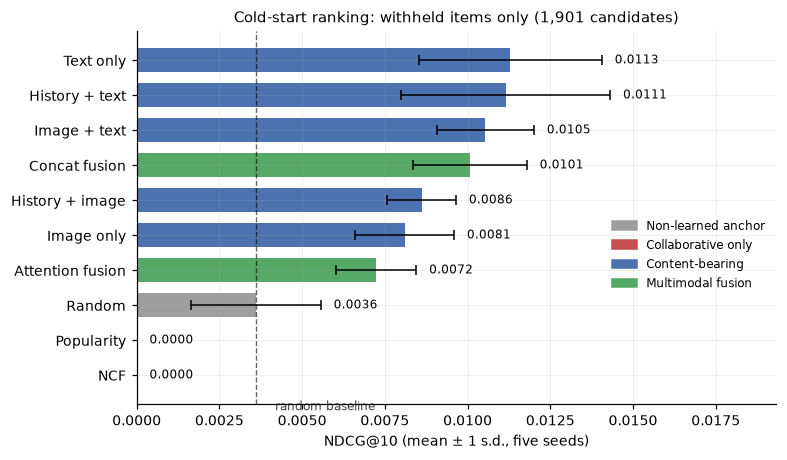

,system,NDCG@10,multiple of random
0,Text only,0.0113 ± 0.0028,3.1
1,History + text,0.0111 ± 0.0032,3.1
2,Image + text,0.0105 ± 0.0015,2.9
3,Concat fusion,0.0101 ± 0.0017,2.8
4,History + image,0.0086 ± 0.0010,2.4
5,Image only,0.0081 ± 0.0015,2.2
6,Attention fusion,0.0072 ± 0.0012,2.0
7,Random,0.0036 ± 0.0020,1.0
8,Popularity,0.0000 ± 0.0000,0.0
9,NCF,0.0000 ± 0.0000,0.0


In [2]:
cold = (aggregate[(aggregate["condition"] == "cold_start")
                  & (aggregate["candidate_pool"] == "cold_only")]
        .sort_values("ndcg_mean"))
random_mean = float(cold.loc[cold["system"] == "random", "ndcg_mean"].iloc[0])

fig, ax = plt.subplots(figsize=(7.5, 4.4))
positions = np.arange(len(cold))
ax.barh(positions, cold["ndcg_mean"], xerr=cold["ndcg_std"],
        color=[COLOURS[family(s)] for s in cold["system"]],
        height=0.68, error_kw={"elinewidth": 1, "capsize": 3})
ax.set_yticks(positions)
ax.set_yticklabels([DISPLAY[s] for s in cold["system"]])
ax.axvline(random_mean, color="black", linestyle="--", linewidth=0.9, alpha=0.6)

limit = (cold["ndcg_mean"] + cold["ndcg_std"]).max() * 1.35
for position, (mean, spread) in enumerate(zip(cold["ndcg_mean"], cold["ndcg_std"])):
    ax.text(mean + spread + limit * 0.02, position, f"{mean:.4f}",
            va="center", fontsize=8)

ax.set_xlim(0, limit)
ax.set_xlabel("NDCG@10 (mean ± 1 s.d., five seeds)")
ax.set_title("Cold-start ranking: withheld items only (1,901 candidates)")
ax.annotate("random baseline", xy=(random_mean, -0.9),
            xytext=(random_mean + limit * 0.03, -0.9),
            fontsize=8, alpha=0.75, va="center", annotation_clip=False)

handles = [plt.Rectangle((0, 0), 1, 1, color=COLOURS[k])
           for k in ("anchor", "collaborative", "content", "fusion")]
ax.legend(handles, ["Non-learned anchor", "Collaborative only",
                    "Content-bearing", "Multimodal fusion"],
          loc="center right", fontsize=8, bbox_to_anchor=(1.0, 0.40))
fig.savefig(FIGURES / "cold_start_ranking.png")
plt.show()

table = cold.sort_values("ndcg_mean", ascending=False).copy()
table["multiple of random"] = (table["ndcg_mean"] / random_mean).round(1)
table["NDCG@10"] = (table["ndcg_mean"].map("{:.4f}".format) + " ± "
                    + table["ndcg_std"].map("{:.4f}".format))
table["system"] = table["system"].map(DISPLAY)
display(table[["system", "NDCG@10", "multiple of random"]].reset_index(drop=True))

**Two systems score exactly zero, with zero variance, across five seeds and
25,656 held-out interactions.**

The popularity baseline ranks items by how often they were purchased during
training. A withheld item was purchased zero times, so it has no popularity score
and cannot outrank any established item. Neural collaborative filtering learns an
embedding for each item from its interactions; a withheld item has none, so its
embedding was never updated and carries no information.

**This is not poor performance. It is a structural inability**, and it is the
problem the project set out to demonstrate.

The content-bearing systems reach roughly three times the random baseline. They
are ranking products nobody has ever purchased, using only the photograph and the
description.

### The harder measurement

The table above ranks withheld items against each other. A deployed catalogue is
different: a new product competes against every established product on the site,
all of which carry purchase history it lacks.

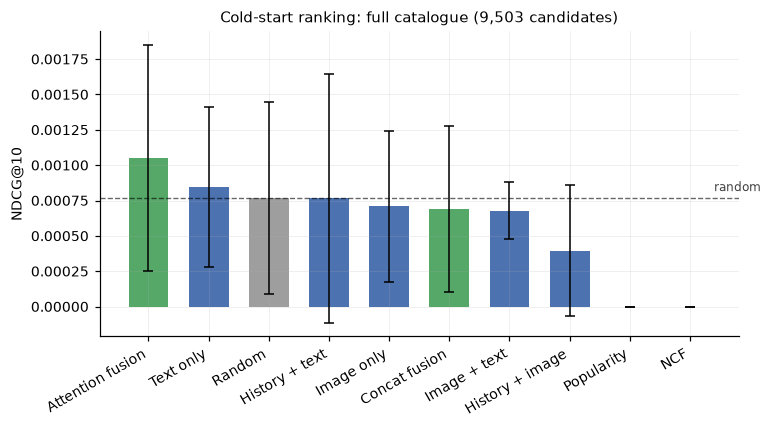

In [3]:
full = (aggregate[(aggregate["condition"] == "cold_start")
                  & (aggregate["candidate_pool"] == "full")]
        .sort_values("ndcg_mean", ascending=False))
random_full = float(full.loc[full["system"] == "random", "ndcg_mean"].iloc[0])

fig, ax = plt.subplots(figsize=(7.5, 3.6))
positions = np.arange(len(full))
ax.bar(positions, full["ndcg_mean"], yerr=full["ndcg_std"],
       color=[COLOURS[family(s)] for s in full["system"]],
       width=0.66, error_kw={"elinewidth": 1, "capsize": 3})
ax.axhline(random_full, color="black", linestyle="--", linewidth=0.9, alpha=0.6)
ax.text(len(full) - 0.6, random_full * 1.06, "random", fontsize=8, alpha=0.75)
ax.set_xticks(positions)
ax.set_xticklabels([DISPLAY[s] for s in full["system"]], rotation=30, ha="right")
ax.set_ylabel("NDCG@10")
ax.set_title("Cold-start ranking: full catalogue (9,503 candidates)")
fig.savefig(FIGURES / "cold_start_full_catalogue.png")
plt.show()

**Against the full catalogue no system reliably exceeds random.** Every content
model's interval overlaps the random baseline's.

Both pools are reported because either alone invites a fair objection. The
restricted pool alone would overstate what the content signals achieve; the full
catalogue alone would suggest they carry no information, which section 5 shows to
be false.

**A caveat that matters for interpretation.** This measures the *average* over
all 1,901 withheld items. It does not measure where the *best* withheld item
lands for a given customer, which is the question a storefront actually asks —
and section 8 shows those answers differ substantially.

## 2. All systems, all conditions

Four conditions were evaluated. **Control** uses every available signal.
**Blind** and **Silent** suppress the image and text respectively in the fully
trained model, measuring how far each system depends on a modality.
**Cold-start** evaluates the withheld items.

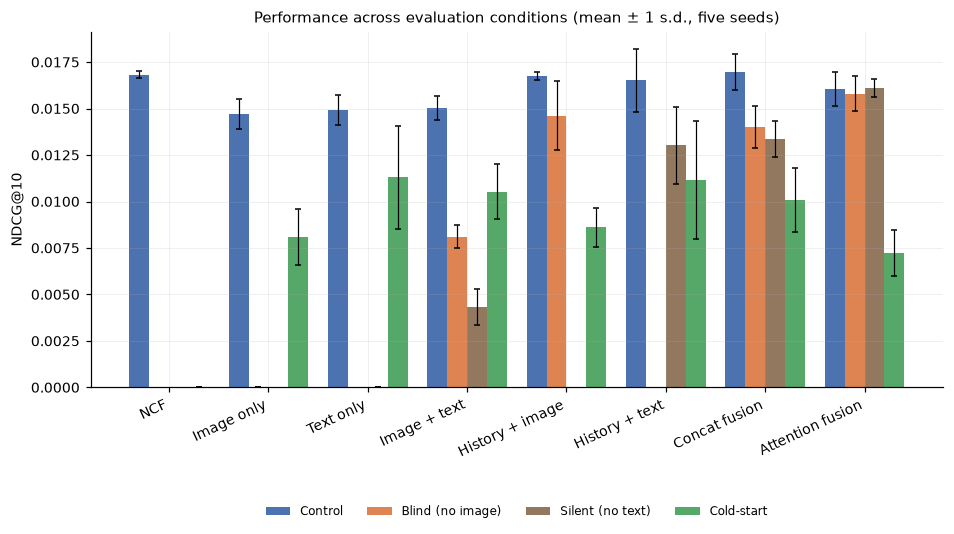

In [4]:
order = ["ncf", "image_only", "text_only", "content_only",
         "interaction_image", "interaction_text", "concat_fusion",
         "attention_fusion"]
conditions = [("control", "full", "Control"),
              ("blind", "full", "Blind (no image)"),
              ("silent", "full", "Silent (no text)"),
              ("cold_start", "cold_only", "Cold-start")]

fig, ax = plt.subplots(figsize=(10, 4.2))
width, positions = 0.2, np.arange(len(order))
palette = ["#4c72b0", "#dd8452", "#937860", "#55a868"]

for index, (condition, pool, label) in enumerate(conditions):
    subset = aggregate[(aggregate["condition"] == condition)
                       & (aggregate["candidate_pool"] == pool)]
    means = dict(zip(subset["system"], subset["ndcg_mean"]))
    spread = dict(zip(subset["system"], subset["ndcg_std"]))
    ax.bar(positions + index * width - 1.5 * width,
           [means.get(s, np.nan) for s in order], width,
           yerr=[spread.get(s, 0.0) for s in order],
           label=label, color=palette[index],
           error_kw={"elinewidth": 0.8, "capsize": 2})

ax.set_xticks(positions)
ax.set_xticklabels([DISPLAY[s] for s in order], rotation=25, ha="right")
ax.set_ylabel("NDCG@10")
ax.set_title("Performance across evaluation conditions (mean ± 1 s.d., five seeds)")
ax.legend(fontsize=8, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.3))
fig.savefig(FIGURES / "condition_comparison.png")
plt.show()

In [5]:
pivot = (aggregate[aggregate["candidate_pool"].isin(["full", "cold_only"])]
         .assign(label=lambda d: d["condition"] + " / " + d["candidate_pool"])
         .pivot_table(index="system", columns="label", values="ndcg_mean")
         .reindex(order).rename(index=DISPLAY).round(4))
pivot

label,blind / full,cold_start / cold_only,cold_start / full,control / full,silent / full
system,,,,,
NCF,NaN,0.0000,0.0000,0.0168,NaN
Image only,0.0000,0.0081,0.0007,0.0147,NaN
Text only,NaN,0.0113,0.0008,0.0149,0.0000
Image + text,0.0081,0.0105,0.0007,0.0150,0.0043
History + image,0.0146,0.0086,0.0004,0.0167,NaN
History + text,NaN,0.0111,0.0008,0.0165,0.0130
Concat fusion,0.0140,0.0101,0.0007,0.0170,0.0134
Attention fusion,0.0158,0.0072,0.0010,0.0160,0.0161


**On established items the ordering is as the proposal predicted.**
`concat_fusion` at 0.0170 beats NCF at 0.0168, text at 0.0149 and image at
0.0147 — all three unimodal baselines. It also beats the popularity anchor at
0.0157, which is a genuinely strong competitor on dense data.

**In the cold-start pool the ordering reverses.** `text_only` leads at 0.0113,
ahead of both fusion models. Sections 5 and 6 establish why.

## 3. Statistical significance

Paired Wilcoxon signed-rank tests over per-user NDCG@10.

**Pairing is over users rather than seeds, and the reason is arithmetic.** With
five seeds the smallest achievable two-sided p-value is 0.0625, because the
statistic derives from the number of distinct sign patterns available and five
pairs admit only thirty-two. Significance at the conventional threshold is
therefore unreachable at the seed level however large the difference. Pairing
users provides thousands of paired observations.

Seeds serve a different purpose, reported throughout as error bars: they
establish that a result is stable across random initialisation.

In [6]:
significance = read("significance_tests.csv", TABLES)
if significance is not None:
    table = significance.copy()
    table["comparison"] = (table["system_a"].map(DISPLAY).fillna(table["system_a"])
                           + "  vs  "
                           + table["system_b"].map(DISPLAY).fillna(table["system_b"]))
    table["p"] = table["p_value"].map(lambda v: f"{v:.3g}")
    table["verdict"] = np.where(table["significant"], "significant", "not significant")
    display(table[["comparison", "condition", "relative_gain_pct", "effect_size",
                   "p", "n_differing", "verdict"]].reset_index(drop=True))

,comparison,condition,relative_gain_pct,effect_size,p,n_differing,verdict
0,Text only vs Attention fusion,cold_start,70.97,0.2581,1.64e-14,744,significant
1,Text only vs Concat fusion,cold_start,6.21,0.0064,0.185,787,not significant
2,Text only vs Image only,cold_start,20.62,0.0922,0.015,846,significant
3,Concat fusion vs Attention fusion,cold_start,60.98,0.2406,7.72e-22,690,significant
4,Concat fusion vs NCF,control,7.53,0.2308,1.15e-06,429,significant
5,Concat fusion vs Popularity,control,15.64,0.3291,1.71e-12,468,significant
6,Attention fusion vs Image + text,silent,165.51,0.4708,1.28e-22,616,significant
7,Text only vs Text only,cold_start,0.00,0.0000,1,0,not significant


### What the tests support

**Established items.** The best learned system beats the popularity anchor by
15.6% (p = 1.7 × 10⁻¹²) and NCF by 7.5% (p = 1.2 × 10⁻⁶), both with substantial
effect sizes. Beating a popularity baseline is a real achievement rather than an
assumed one.

**Text carries more cold-start signal than images**, +20.6% at p = 0.015. This
confirms a prediction recorded in notebook 2 from the semantic margins, before
any model was trained.

**Fusion and text alone are statistically indistinguishable at cold-start** —
+6.2%, p = 0.185, with wins split 396 to 391 across users. The defensible
statement is that fusion does not beat the best single content signal in this
regime, not that it loses to it.

### A caution on power

**Only 3–4% of user pairs have differing scores.** NDCG@10 is zero for both
systems whenever neither ranks the target inside the top ten, which is the common
case at these performance levels. The comparisons therefore rest on roughly
500–800 informative pairs rather than the full sample.

The tests reported here come from a single evaluation seed and should be read
alongside the across-seed spreads rather than as an aggregate.

## 4. Which modality does each system actually use?

Removing a modality from a fully trained model measures how far it relied on
that signal.

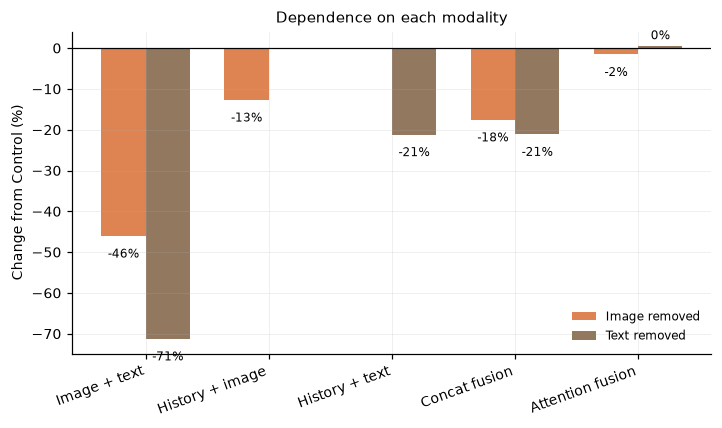

In [7]:
control = (aggregate[(aggregate["condition"] == "control")
                     & (aggregate["candidate_pool"] == "full")]
           .set_index("system")["ndcg_mean"])

rows = []
for condition, label in (("blind", "Image removed"), ("silent", "Text removed")):
    subset = aggregate[(aggregate["condition"] == condition)
                       & (aggregate["candidate_pool"] == "full")]
    for row in subset.itertuples():
        if row.system in control.index and control[row.system] > 0:
            rows.append({"system": row.system, "condition": label,
                         "change": (row.ndcg_mean - control[row.system])
                                   / control[row.system] * 100})

degradation = pd.DataFrame(rows)
present = [s for s in ["content_only", "interaction_image", "interaction_text",
                       "concat_fusion", "attention_fusion"]
           if s in set(degradation["system"])]

fig, ax = plt.subplots(figsize=(7.5, 3.8))
width, positions = 0.36, np.arange(len(present))
for index, (label, colour) in enumerate([("Image removed", "#dd8452"),
                                         ("Text removed", "#937860")]):
    values = degradation[degradation["condition"] == label].set_index("system")["change"]
    heights = [values.get(s, np.nan) for s in present]
    bars = ax.bar(positions + index * width - width / 2, heights, width,
                  label=label, color=colour)
    for bar, value in zip(bars, heights):
        if not np.isnan(value):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    value - 3 if value < 0 else value + 1, f"{value:.0f}%",
                    ha="center", va="top" if value < 0 else "bottom", fontsize=8)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(positions)
ax.set_xticklabels([DISPLAY[s] for s in present], rotation=20, ha="right")
ax.set_ylabel("Change from Control (%)")
ax.set_title("Dependence on each modality")
ax.legend(fontsize=8)
fig.savefig(FIGURES / "modality_dependence.png")
plt.show()

**The two fusion designs behave very differently.**

`concat_fusion` loses roughly a fifth of its performance when either modality is
removed, indicating both contribute materially to its predictions.

`attention_fusion` is almost unaffected — and removing text slightly *improved*
it. **A model that does not degrade when a signal is removed was not using that
signal.** Despite having access to both content modalities, it is effectively
operating on purchase history alone.

This corroborates the attention weights in notebook 2, which showed 70% of the
attention mass on the collaborative signal. Two independent methods agree, and
together they explain why `attention_fusion` is the weakest content-bearing
system at cold-start: its content pathways never developed during training.

## 5. Why images contribute less than text

Every system containing images performs worse than its text-only counterpart, at
every combination. Five independent measurements explain why.

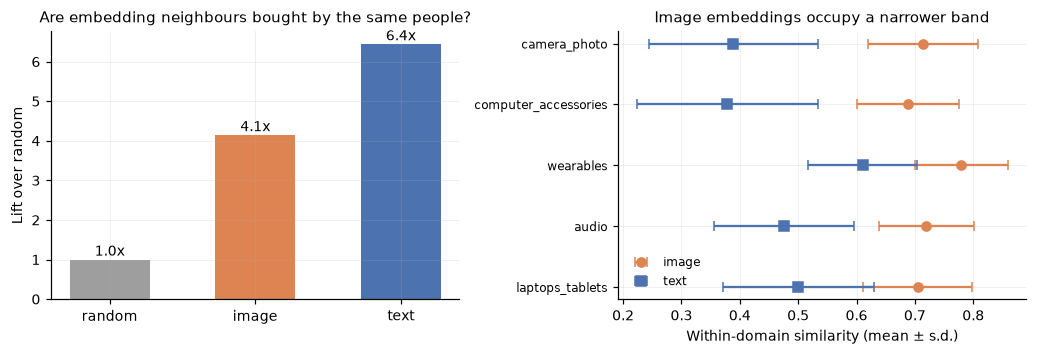

,image,text,random
0,0.032769,0.050923,0.007905


In [8]:
neighbour = read("neighbour_copurchase.csv")
spread = read("embedding_spread.csv")

if neighbour is not None:
    values = neighbour.iloc[0]
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.3))

    labels = ["random", "image", "text"]
    lifts = [1.0, values["image"] / values["random"], values["text"] / values["random"]]
    axes[0].bar(labels, lifts, color=["#9e9e9e", "#dd8452", "#4c72b0"], width=0.55)
    for x, value in enumerate(lifts):
        axes[0].text(x, value + 0.1, f"{value:.1f}x", ha="center", fontsize=9)
    axes[0].set_ylabel("Lift over random")
    axes[0].set_title("Are embedding neighbours bought by the same people?")

    if spread is not None:
        positions = np.arange(len(spread))
        axes[1].errorbar(spread["image_mean"], positions, xerr=spread["image_std"],
                         fmt="o", color="#dd8452", label="image", capsize=3)
        axes[1].errorbar(spread["text_mean"], positions, xerr=spread["text_std"],
                         fmt="s", color="#4c72b0", label="text", capsize=3)
        axes[1].set_yticks(positions)
        axes[1].set_yticklabels(spread["domain"], fontsize=8)
        axes[1].set_xlabel("Within-domain similarity (mean ± s.d.)")
        axes[1].set_title("Image embeddings occupy a narrower band")
        axes[1].legend(fontsize=8)

    fig.tight_layout()
    fig.savefig(FIGURES / "why_images_underperform.png")
    plt.show()
    display(neighbour)

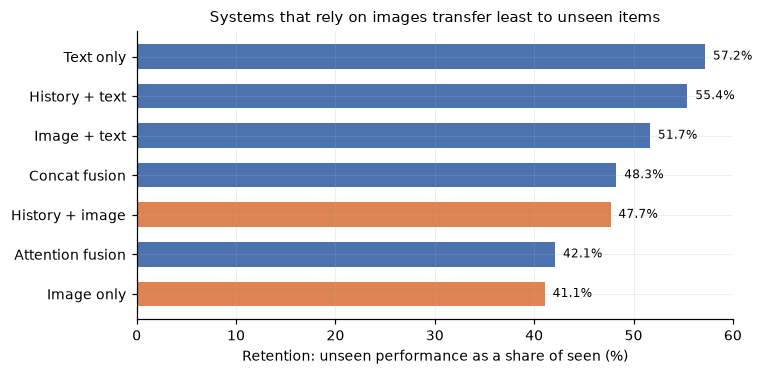

,system,seen,seen_sd,unseen,unseen_sd,retention
0,text_only,0.0198,0.0008,0.0113,0.0028,0.5720
1,interaction_text,0.0198,0.0035,0.0112,0.0032,0.5542
2,content_only,0.0204,0.0008,0.0105,0.0015,0.5166
3,concat_fusion,0.0208,0.0015,0.0101,0.0017,0.4827
4,interaction_image,0.0184,0.0033,0.0086,0.0010,0.4769
5,attention_fusion,0.0173,0.0016,0.0072,0.0012,0.4210
6,image_only,0.0197,0.0012,0.0081,0.0015,0.4107


In [9]:
generalisation = read("generalisation_gap.csv")
if generalisation is not None:
    table = generalisation.sort_values("retention", ascending=False)
    fig, ax = plt.subplots(figsize=(7, 3.4))
    positions = np.arange(len(table))
    colours = ["#4c72b0" if "image" not in s else "#dd8452" for s in table["system"]]
    ax.barh(positions, table["retention"] * 100, color=colours, height=0.62)
    ax.set_yticks(positions)
    ax.set_yticklabels([DISPLAY.get(s, s) for s in table["system"]])
    ax.invert_yaxis()
    ax.set_xlabel("Retention: unseen performance as a share of seen (%)")
    ax.set_title("Systems that rely on images transfer least to unseen items")
    for y, value in enumerate(table["retention"] * 100):
        ax.text(value + 0.8, y, f"{value:.1f}%", va="center", fontsize=8)
    fig.savefig(FIGURES / "generalisation_retention.png")
    plt.show()
    display(table.round(4))

### The mechanism

**Images carry genuine preference signal, but less than text.** Image
nearest-neighbours are co-purchased at 4.1 times random against text's 6.4 —
roughly 55% weaker. That ratio of 1.55 closely predicts the observed performance
ratio of 1.40 between `text_only` and `image_only`.

**Image embeddings occupy a narrow band.** Within a domain they sit around
0.69–0.78 with a standard deviation near 0.08, against text's 0.38–0.61 with
deviations up to 0.16. E-commerce photography is uniform: white backgrounds,
studio lighting, similar framing.

**The consequence is transfer, not pathway quality.** Measured content-only
performance on *seen* items has `concat_fusion` highest at 0.0204, above
`text_only`. On *unseen* items the ordering reverses. Retention orders exactly by
image dependence — no image 57.2% and 55.4%, image as one of several signals
51.7% down to 42.1%, image alone 41.1%.

A projection trained on a compressed space learns to amplify small differences,
and those differences are item-specific rather than transferable.

## 6. Six alternative explanations, tested and eliminated

Each was piloted at 10–45 minutes rather than committed to as a multi-hour
retrain. Four of the six refuted a hypothesis held at the time.

In [10]:
eliminated = pd.DataFrame([
    ("Content pathway undertrained",
     "auxiliary content-only loss, full gradient every batch",
     "content-only score fell 4.8%", "refuted"),
    ("Image embeddings too compressed",
     "PCA whitening, fitted on training items only",
     "retention fell: 53.0% to 47.0% and 67.4% to 53.6%", "refuted"),
    ("Training stopped too early",
     "60 epochs, no early stopping, cold-start proxy tracked",
     "text_only wins under every selection rule", "refuted"),
    ("Selection criterion misaligned",
     "checkpoint selection on a cold-start proxy",
     "changed cold-start NDCG by 0.0001", "refuted"),
    ("Only one image per product used",
     "four views downloaded and encoded separately",
     "images do differ, mean similarity 0.72", "confirmed as a limitation"),
    ("Multiple views would close the gap",
     "eight combination strategies compared on co-purchase lift",
     "best gives 3.3x against text's 3.8x, a 9% gain", "refuted"),
], columns=["hypothesis", "test", "result", "verdict"])
eliminated

,hypothesis,test,result,verdict
0,Content pathway undertrained,"auxiliary content-only loss, full gradient eve...",content-only score fell 4.8%,refuted
1,Image embeddings too compressed,"PCA whitening, fitted on training items only",retention fell: 53.0% to 47.0% and 67.4% to 53.6%,refuted
2,Training stopped too early,"60 epochs, no early stopping, cold-start proxy...",text_only wins under every selection rule,refuted
3,Selection criterion misaligned,checkpoint selection on a cold-start proxy,changed cold-start NDCG by 0.0001,refuted
4,Only one image per product used,four views downloaded and encoded separately,"images do differ, mean similarity 0.72",confirmed as a limitation
5,Multiple views would close the gap,eight combination strategies compared on co-pu...,"best gives 3.3x against text's 3.8x, a 9% gain",refuted


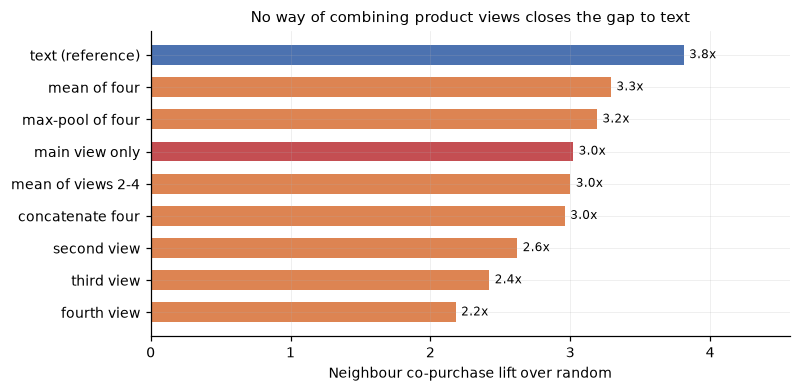

,strategy,neighbour_rate,lift,mean_neighbour_similarity
0,text (reference),0.04824,3.81,0.7166
1,mean of four,0.04172,3.29,0.8958
2,max-pool of four,0.04037,3.19,0.8606
3,main view only,0.03828,3.02,0.8634
4,mean of views 2-4,0.03797,3.00,0.8675
5,concatenate four,0.03751,2.96,0.7547
6,second view,0.03324,2.62,0.7831
7,third view,0.03063,2.42,0.7764
8,fourth view,0.02769,2.18,0.7658


In [11]:
views = read("view_strategy_comparison.csv")
if views is not None:
    table = views.sort_values("lift")
    fig, ax = plt.subplots(figsize=(7.5, 3.6))
    colours = ["#4c72b0" if "text" in s else
               ("#c44e52" if "main" in s else "#dd8452")
               for s in table["strategy"]]
    positions = np.arange(len(table))
    ax.barh(positions, table["lift"], color=colours, height=0.62)
    ax.set_yticks(positions)
    ax.set_yticklabels(table["strategy"])
    ax.set_xlabel("Neighbour co-purchase lift over random")
    ax.set_title("No way of combining product views closes the gap to text")
    for y, value in enumerate(table["lift"]):
        ax.text(value + 0.04, y, f"{value:.1f}x", va="center", fontsize=8)
    ax.set_xlim(0, table["lift"].max() * 1.2)
    fig.savefig(FIGURES / "view_strategies.png")
    plt.show()
    display(views)

**Products carry a median of four images and only one was used.** That is a real
limitation, and the images genuinely differ — a product's own views sit at mean
similarity 0.72, with 68.8% of pairs below 0.80.

**But no combination strategy closes the gap.** The best, averaging four views,
lifts co-purchase from 3.0 to 3.3 against text's 3.8 — a 9% gain against a 27%
gap. The main image is the most informative and each additional view is
progressively weaker.

A related finding: averaging views pushes *different* products closer together,
from 0.64 to 0.72, because averaging cancels what distinguishes each view and
leaves the generic studio appearance they share. **The obvious remedy is
provably counterproductive.**

## 7. Where cold-start ranking succeeds and fails

The aggregate score is an average. This examines retrieval quality per item.

In [12]:
per_item = read("cold_start_per_item_concat_fusion_seed1.csv", TABLES)
if per_item is not None:
    per_item["retrieved"] = per_item["mean_ndcg"] > 0
    retrieved = per_item[per_item["retrieved"]]
    print(f"withheld items          : {len(per_item):,}")
    print(f"retrieved at least once : {len(retrieved):,} "
          f"({len(retrieved)/len(per_item):.1%})")
    print(f"mean NDCG@10 if retrieved: {retrieved['mean_ndcg'].mean():.4f}")

    comparison = (per_item.groupby("retrieved")
                  .agg(items=("item_idx", "size"),
                       median_text_length=("text_length", "median"),
                       median_title_length=("title_length", "median"),
                       with_description=("has_description", "mean"),
                       with_image=("has_image", "mean"),
                       median_corpus_interactions=("corpus_interactions", "median"))
                  .round(3)
                  .rename(index={False: "never retrieved", True: "retrieved"}))
    display(comparison.T)

withheld items          : 1,901
retrieved at least once : 52 (2.7%)
mean NDCG@10 if retrieved: 0.2063


retrieved,never retrieved,retrieved
items,1849.000,52.000
median_text_length,1580.000,1593.000
median_title_length,132.000,123.000
with_description,0.617,0.596
with_image,1.000,1.000
median_corpus_interactions,12.000,18.000


**Content quality does not separate the two groups.** Text length, title length,
description availability and image coverage are effectively identical between
items that are retrieved and items that never are.

**The only difference is prior popularity** — a median of 18 interactions against
12.

That is a substantive finding. Even in the cold-start condition, where purchase
history is withheld and the model can see only photographs and words, it is
still surfacing products that were already popular. The content signals are not
distinguishing items on their own merits; they are picking up something that
correlates with popularity — probably better photography and more conventional
descriptions on established products.

**This is the clearest limitation of the approach**, and it belongs in the
report's Challenges section.

## 8. The deployed view

The aggregate averages over all 1,901 withheld items. A storefront asks a
narrower question: for a given customer, where does the *best* new product land?

Both models scored all 9,503 products for six curated customers.

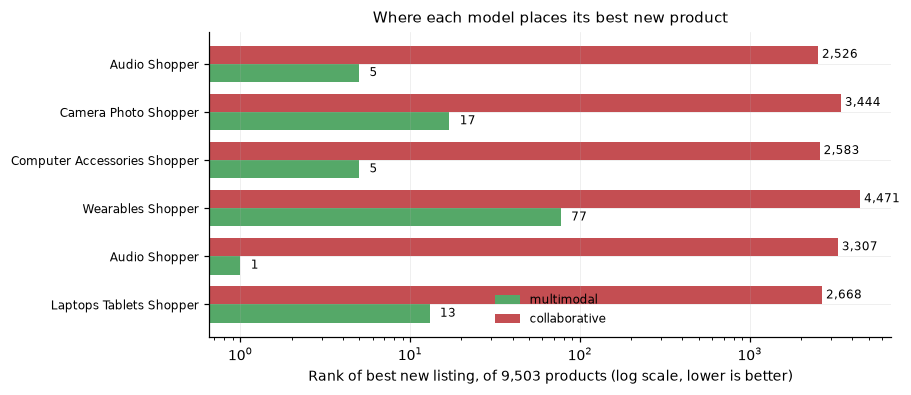

,customer,multimodal,collaborative,distinct collaborative scores
0,Laptops Tablets Shopper,13,2668,1
1,Audio Shopper,1,3307,1
2,Wearables Shopper,77,4471,1
3,Computer Accessories Shopper,5,2583,1
4,Camera Photo Shopper,17,3444,1
5,Audio Shopper,5,2526,1


In [13]:
demo_path = PROJECT / "demo" / "demo_data.json"
if demo_path.exists():
    demo = json.loads(demo_path.read_text())
    ranks = pd.DataFrame([{
        "customer": c["label"],
        "multimodal": c["best_new_rank_multimodal"],
        "collaborative": c["best_new_rank_collaborative"],
        "distinct collaborative scores": c["distinct_collaborative"],
    } for c in demo["customers"]])

    fig, ax = plt.subplots(figsize=(8, 3.6))
    positions = np.arange(len(ranks))
    ax.barh(positions - 0.19, ranks["multimodal"], 0.38,
            label="multimodal", color="#55a868")
    ax.barh(positions + 0.19, ranks["collaborative"], 0.38,
            label="collaborative", color="#c44e52")
    ax.set_yticks(positions)
    ax.set_yticklabels(ranks["customer"], fontsize=8)
    ax.set_xscale("log")
    ax.set_xlabel(f"Rank of best new listing, of {demo['n_total']:,} products "
                  f"(log scale, lower is better)")
    ax.set_title("Where each model places its best new product")
    ax.legend(fontsize=8)
    for y, value in enumerate(ranks["multimodal"]):
        ax.text(value * 1.15, y - 0.19, f"{value:,}", va="center", fontsize=8)
    for y, value in enumerate(ranks["collaborative"]):
        ax.text(value * 1.05, y + 0.19, f"{value:,}", va="center", fontsize=8)
    fig.savefig(FIGURES / "deployed_ranking.png")
    plt.show()
    display(ranks)

**The multimodal model places a brand-new product at rank 1 for one customer and
within the top 20 for four of six.** The collaborative model buries its best at
rank 2,500–4,500.

**And it assigns a single distinct score to all 1,901 new listings.** Its item
representations are learned from purchases; these products have none, so it
cannot tell them apart and the ordering among them is arbitrary.

This is consistent with the aggregate rather than in tension with it. The
aggregate averages over every withheld item, most of which never surface. This
measures the best one, which is what a storefront places.

## 9. What the evidence supports

**Collaborative filtering fails categorically on unseen items.** Popularity and
NCF score exactly 0.0000 ± 0.0000 across five seeds and 25,656 interactions. A
structural inability, not a matter of degree.

**Content signals provide measurable cold-start capability** — up to three times
random on the restricted pool, and a best new listing at rank 1 of 9,503 for one
customer.

**Text outperforms images for cold-start**, +20.6% at p = 0.015, confirming a
prediction made from feature validation before training.

**Multimodal fusion does not beat the best single content signal in this sparse
regime.** A negative result against the project's own hypothesis, reported as
such, with six alternative explanations tested and eliminated.

**On established items the fusion model does beat every unimodal baseline** and
the popularity anchor, by 15.6% at p = 1.7 × 10⁻¹².

**Attention fusion under-develops its content pathways**, shown independently by
attention weights and by modality suppression.

**Single-seed selection produces optimistically biased results** — measured at up
to 3.2 standard deviations.

## 10. Actionable insights

**Content-based ranking is necessary for any catalogue with turnover.** A
collaborative recommender assigns one identical score to every new listing. A
retailer relying on one has no mechanism to place new products at all, whatever
its performance on established stock.

**Product text is the more valuable content investment.** Text outperforms images
on every measurement taken — semantic separation, co-purchase lift, transfer to
unseen items, and cold-start ranking. A retailer improving cold-start should
invest in descriptions before photography.

**Uniform product photography limits what vision models contribute.** Standard
white-background studio imagery compresses embeddings into a narrow band, and no
combination of multiple views recovers the difference. Differentiated imagery —
in context, in use, at varied scale — would be required for images to contribute
as text does.

**Deploy content-based ranking in bounded placements.** New listings do not
outrank established products in a full-catalogue ranking, and should not be
expected to. They rank well within new-arrival shelves, category pages and
search results, which is where the mechanism belongs.

**Measure coverage alongside accuracy.** Accuracy metrics cannot distinguish a
personalised recommender from one that has collapsed onto popularity. In this
project a model matched a non-learned baseline's behaviour while its accuracy
score concealed it entirely.

## 11. Limitations

**Absolute values are small.** NDCG@10 near 0.017 reflects ranking one held-out
item among 7,602 candidates on a matrix with roughly twelve interactions per
item. The spread across eight architecturally different systems is under 15%,
which indicates warm-start ranking is near a ceiling in this regime.

**No system beats random on the full cold-start catalogue.**

**The 5% success criterion is not met on five-seed means** for the cold-start
condition.

**Significance testing covers one evaluation seed**, not the aggregate, and rests
on 500–800 informative pairs because most user scores are zero for both systems.

**Cold-start retrieval correlates with prior popularity** rather than with
content quality — section 7.

**One image per product was used** where a median of four were available.
Section 6 establishes that using all four would not close the gap, but the
limitation stands.

**The corpus is a dense subsample.** 87.5% of users touch a single domain and were
excluded. Conclusions concern model behaviour under cold-start, not the average
shopper.